# Early Stopping and Regularization

**Unit:** Unit 4: Neural Networks Fundamentals

**Why this notebook?** A big neural network can get a *perfect* score on its
training data and still be bad at its actual job. On small, noisy datasets the
network stops learning the real pattern and starts memorizing the noise — this
is **overfitting**, and it is the single most common failure mode you will hit
when training neural networks. In this notebook we overfit a network *on
purpose*, learn to spot the damage in the training curves, and then compare
three standard fixes — early stopping, dropout, and L2 weight regularization —
on exactly the same data so the numbers are directly comparable.

## 📚 Learning Objectives

By completing this notebook, you will:
- Diagnose overfitting from train-vs-validation curves
- Stop training at the right moment with the `EarlyStopping` callback
- Reduce memorization with `Dropout` layers
- Penalize large weights with L2 regularization
- Compare all three fixes in one summary table and pick a winner

## 🔗 Prerequisites

- ✅ Basic Python and NumPy
- ✅ Building a small Keras model (`Sequential`, `Dense`, `fit`) from the earlier Unit 3/4 notebooks

---

## The Experiment Plan

We teach this comparatively — one baseline, then change **one thing at a time**:

1. **Baseline:** train a deliberately *too-big* MLP on a small noisy dataset and watch it overfit.
2. **Fix 1 — Early stopping:** same model, but stop training when validation loss stops improving.
3. **Fix 2 — Dropout:** same model, but randomly drop 30% of hidden activations during training.
4. **Fix 3 — L2:** same model, but penalize large weights in the loss function.

**The dataset:** `make_classification` gives us a synthetic binary classification
problem where we control the difficulty. We use only **600 samples** (300 train /
300 validation) and flip **15% of the labels** at random — so the data is small
*and* noisy, which is exactly the situation where overfitting bites hardest.
Because 15% of labels are pure noise, *no* model can honestly score much above
~85% validation accuracy — anything that pushes training accuracy to 100% is
memorizing noise, not learning.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

print("=== Dataset: small and noisy on purpose ===")
X, y = make_classification(
    n_samples=600,        # small dataset
    n_features=20,
    n_informative=8,      # only 8 features actually matter
    n_redundant=4,
    flip_y=0.15,          # 15% of labels randomly flipped = label noise
    class_sep=1.2,
    random_state=7,
)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.5, stratify=y, random_state=7
)

print(f"Training set:   {X_train.shape[0]} samples x {X_train.shape[1]} features")
print(f"Validation set: {X_val.shape[0]} samples x {X_val.shape[1]} features")
print(f"Class balance (train): {np.bincount(y_train)}")
print("Label noise: ~15% of labels were flipped at random (flip_y=0.15),")
print("so ~85% validation accuracy is the realistic ceiling here.")

=== Dataset: small and noisy on purpose ===
Training set:   300 samples x 20 features
Validation set: 300 samples x 20 features
Class balance (train): [148 152]
Label noise: ~15% of labels were flipped at random (flip_y=0.15),
so ~85% validation accuracy is the realistic ceiling here.


## Step 1 — Deliberately Overfit a Too-Big MLP

**What:** an MLP with hidden layers of 256 → 256 → 128 units — over **100,000
trainable parameters** — trained on just **300 rows** for 150 epochs.

**Why this is asking for trouble:** with ~350 parameters *per training sample*,
the network has more than enough capacity to memorize every row, including the
15% of labels that are pure noise.

**How we detect the damage:** we track loss and accuracy on the *validation*
set after every epoch. Memorization drives training loss to ~0 while validation
loss gets *worse* — that widening gap is the signature of overfitting.

All four experiments below share the same `build_model` / `train_and_eval`
helpers, the same random seed, and the same 150-epoch budget, so any difference
in the results comes from the single change we make each time.

In [2]:
EPOCHS = 150
HIDDEN = [256, 256, 128]

def build_model(dropout=0.0, l2_lambda=0.0):
    """Same architecture every time; dropout / L2 are the only knobs."""
    keras.utils.set_random_seed(42)   # identical init for every experiment
    layers = [Input(shape=(X_train.shape[1],))]
    for units in HIDDEN:
        reg = l2(l2_lambda) if l2_lambda > 0 else None
        layers.append(Dense(units, activation="relu", kernel_regularizer=reg))
        if dropout > 0:
            layers.append(Dropout(dropout))
    layers.append(Dense(1, activation="sigmoid"))
    model = Sequential(layers)
    model.compile(optimizer="adam", loss="binary_crossentropy",
                  metrics=["accuracy"])
    return model

results = {}   # name -> dict of final metrics
histories = {} # name -> keras History

def train_and_eval(name, model, callbacks=None):
    history = model.fit(X_train, y_train, validation_data=(X_val, y_val),
                        epochs=EPOCHS, batch_size=32, verbose=0,
                        callbacks=callbacks or [])
    tr_loss, tr_acc = model.evaluate(X_train, y_train, verbose=0)
    va_loss, va_acc = model.evaluate(X_val, y_val, verbose=0)
    results[name] = {"train_acc": tr_acc, "val_acc": va_acc,
                     "gap": tr_acc - va_acc, "val_loss": va_loss,
                     "epochs_run": len(history.history["loss"])}
    histories[name] = history
    print(f"{name}:")
    print(f"  epochs run          : {len(history.history['loss'])}")
    print(f"  final train accuracy: {tr_acc:.3f}")
    print(f"  final val accuracy  : {va_acc:.3f}   (gap: {tr_acc - va_acc:+.3f})")
    print(f"  final val loss      : {va_loss:.3f}")
    return history

print("=== Baseline: too-big MLP, no regularization ===")
baseline = build_model()
print(f"Trainable parameters: {baseline.count_params():,} "
      f"(~{baseline.count_params() // X_train.shape[0]} per training sample!)\n")
h_base = train_and_eval("Baseline (no regularization)", baseline)

best_ep = int(np.argmin(h_base.history["val_loss"])) + 1
print(f"\nVal loss was best at epoch {best_ep} "
      f"({min(h_base.history['val_loss']):.3f}) and then got WORSE "
      f"({h_base.history['val_loss'][-1]:.3f} by epoch {EPOCHS}).")

=== Baseline: too-big MLP, no regularization ===
Trainable parameters: 104,193 (~347 per training sample!)



Baseline (no regularization):
  epochs run          : 150
  final train accuracy: 1.000
  final val accuracy  : 0.823   (gap: +0.177)
  final val loss      : 1.741

Val loss was best at epoch 4 (0.376) and then got WORSE (1.741 by epoch 150).


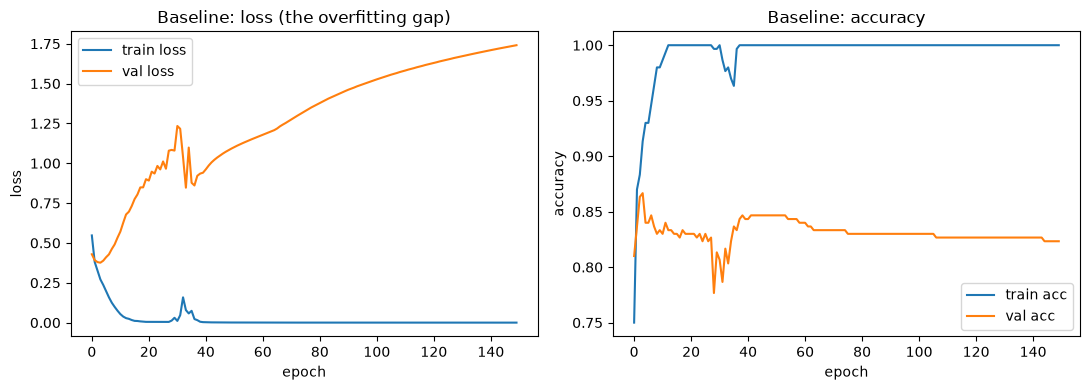

In [3]:
# Plot the train-vs-validation curves for the baseline
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(h_base.history["loss"], label="train loss")
axes[0].plot(h_base.history["val_loss"], label="val loss")
axes[0].set_title("Baseline: loss (the overfitting gap)")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss"); axes[0].legend()

axes[1].plot(h_base.history["accuracy"], label="train acc")
axes[1].plot(h_base.history["val_accuracy"], label="val acc")
axes[1].set_title("Baseline: accuracy")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("accuracy"); axes[1].legend()

plt.tight_layout()
plt.show()

## Reading the Curves

The plots above are the classic overfitting picture:

- **Training** loss keeps falling toward 0 and training accuracy reaches
  **1.000** — the network memorized all 300 rows, *including the ~15% of
  flipped labels*.
- **Validation** loss improves only for the first few epochs (best around
  epoch 4), then trends upward for the rest of training (apart from a brief
  wobble around epoch 30). By the end, validation loss is several times worse
  than at its best point (0.376 → 1.741).
- Validation accuracy hovers around 0.82-0.85 and ends at 0.823 while
  training accuracy is perfect — that **train-vs-val gap of ~0.18** is the
  damage.

Key insight: the model was at its *best* very early. Every epoch after that
made it better at the training set and worse at its real job. Now let's fix it
— one technique at a time, everything else identical.

## Fix 1 — Early Stopping

**What:** stop training when validation loss stops improving, instead of
running the full 150 epochs.

**Why:** the baseline curves showed the best model existed around epoch 4 —
after that, training only added memorization. Early stopping simply *quits
while we're ahead*.

**How:** Keras's `EarlyStopping` callback watches `val_loss`; if it hasn't
improved for `patience=15` epochs, training stops and
`restore_best_weights=True` rewinds the model to its best epoch.

In [4]:
print("=== Fix 1: EarlyStopping callback ===")
early_stop = EarlyStopping(monitor="val_loss", patience=15,
                           restore_best_weights=True)
h_es = train_and_eval("Early stopping", build_model(), callbacks=[early_stop])

base = results["Baseline (no regularization)"]
es = results["Early stopping"]
print(f"\nCompare: stopped after {es['epochs_run']} epochs instead of {EPOCHS},")
print(f"and val accuracy moved {base['val_acc']:.3f} -> {es['val_acc']:.3f} "
      f"({es['val_acc'] - base['val_acc']:+.3f}).")

=== Fix 1: EarlyStopping callback ===


Early stopping:
  epochs run          : 19
  final train accuracy: 0.930
  final val accuracy  : 0.867   (gap: +0.063)
  final val loss      : 0.376

Compare: stopped after 19 epochs instead of 150,
and val accuracy moved 0.823 -> 0.867 (+0.043).


## Fix 2 — Dropout

**What:** during training, each `Dropout(0.3)` layer randomly zeroes 30% of
the activations coming out of the hidden layer below it (dropout is switched
off automatically at evaluation time).

**Why:** if a unit can vanish at any moment, the network cannot rely on any
single unit to memorize a specific training row — it is pushed toward
redundant, more general features.

**How:** same architecture and 150-epoch budget as the baseline; the *only*
change is a `Dropout(0.3)` after each hidden layer.

In [5]:
print("=== Fix 2: Dropout(0.3) after each hidden layer ===")
h_do = train_and_eval("Dropout 0.3", build_model(dropout=0.3))

do = results["Dropout 0.3"]
print(f"\nCompare: val accuracy {base['val_acc']:.3f} -> {do['val_acc']:.3f} "
      f"({do['val_acc'] - base['val_acc']:+.3f}) with the same 150 epochs.")

=== Fix 2: Dropout(0.3) after each hidden layer ===


Dropout 0.3:
  epochs run          : 150
  final train accuracy: 1.000
  final val accuracy  : 0.837   (gap: +0.163)
  final val loss      : 1.570

Compare: val accuracy 0.823 -> 0.837 (+0.013) with the same 150 epochs.


## Fix 3 — L2 Weight Regularization

**What:** add a penalty `l2_lambda * sum(weights**2)` to the loss for every
hidden layer (`l2_lambda = 0.05` here).

**Why:** memorizing noisy labels typically needs large, very specific weights.
Punishing weight magnitude makes memorization *expensive*, so the optimizer
prefers smaller, smoother solutions that generalize better.

**How:** same architecture and budget; the only change is
`kernel_regularizer=l2(0.05)` on each hidden `Dense` layer. Note the small
training-set here needs a fairly strong penalty — the textbook default of 0.01
was too weak to stop a 100k-parameter network in our tests.

In [6]:
print("=== Fix 3: L2 weight regularization (lambda = 0.05) ===")
h_l2 = train_and_eval("L2 (lambda=0.05)", build_model(l2_lambda=0.05))

l2r = results["L2 (lambda=0.05)"]
print(f"\nCompare: val accuracy {base['val_acc']:.3f} -> {l2r['val_acc']:.3f} "
      f"({l2r['val_acc'] - base['val_acc']:+.3f}), and train accuracy is no")
print(f"longer a perfect 1.000 ({l2r['train_acc']:.3f}) — the penalty made "
      f"memorization too expensive.")

=== Fix 3: L2 weight regularization (lambda = 0.05) ===


L2 (lambda=0.05):
  epochs run          : 150
  final train accuracy: 0.927
  final val accuracy  : 0.837   (gap: +0.090)
  final val loss      : 0.504

Compare: val accuracy 0.823 -> 0.837 (+0.013), and train accuracy is no
longer a perfect 1.000 (0.927) — the penalty made memorization too expensive.


## Side-by-Side Comparison

Same data, same architecture, same seed, same epoch budget — one summary
table, plus the validation-loss curves of all four runs on one plot.

=== Summary: validation accuracy per approach ===
                              epochs_run  train_acc  val_acc    gap  val_loss
Baseline (no regularization)         150      1.000    0.823  0.177     1.741
Early stopping                        19      0.930    0.867  0.063     0.376
Dropout 0.3                          150      1.000    0.837  0.163     1.570
L2 (lambda=0.05)                     150      0.927    0.837  0.090     0.504


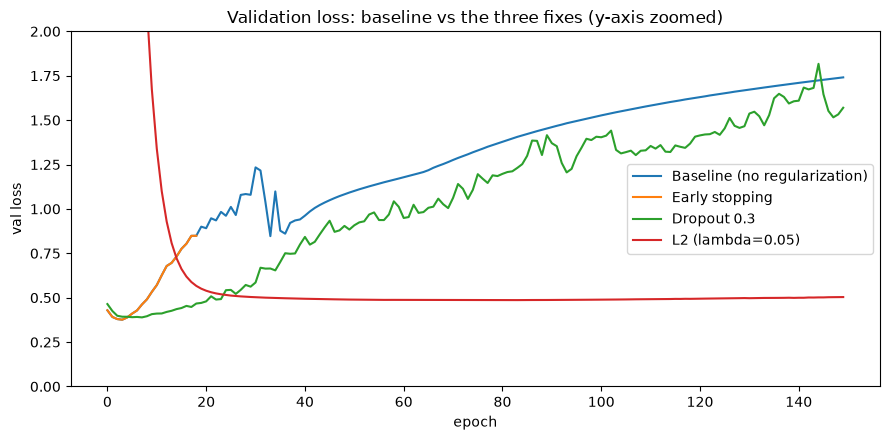

Note: the L2 curve's reported loss includes the weight penalty itself;
it drops into the zoomed view within the first ~10 epochs, settles by
~epoch 20, and then stays flat for the rest of training.


In [7]:
print("=== Summary: validation accuracy per approach ===")
summary = pd.DataFrame(results).T
summary = summary[["epochs_run", "train_acc", "val_acc", "gap", "val_loss"]]
summary["epochs_run"] = summary["epochs_run"].astype(int)
print(summary.round(3).to_string())

fig, ax = plt.subplots(figsize=(9, 4.5))
for name, h in histories.items():
    ax.plot(h.history["val_loss"], label=name)
# Note: Keras reports loss INCLUDING the L2 weight penalty, so the L2 curve
# starts near 19 (huge penalty at random init) — we zoom in to compare shapes.
ax.set_ylim(0, 2.0)
ax.set_title("Validation loss: baseline vs the three fixes (y-axis zoomed)")
ax.set_xlabel("epoch"); ax.set_ylabel("val loss")
ax.legend()
plt.tight_layout()
plt.show()
print("Note: the L2 curve's reported loss includes the weight penalty itself;")
print("it drops into the zoomed view within the first ~10 epochs, settles by")
print("~epoch 20, and then stays flat for the rest of training.")

## Conclusions (from the actual table above)

- **Every fix beat the baseline's final validation accuracy (0.823).** The
  baseline memorized the training set (train accuracy 1.000) and paid for it
  with the worst validation loss by far.
- **Early stopping won here: 0.867 validation accuracy** — and it was also the
  *cheapest*, training for only ~19 epochs instead of 150. It simply returned
  the model from its best epoch, before memorization set in.
- **Dropout (0.837) and L2 (0.837) each recovered part of the loss** but, with
  a 150-epoch budget on this small dataset, neither matched early stopping on
  its own. L2 was the only *full-length* run to end with training accuracy
  below 1.000 (0.927) — it made memorization itself expensive rather than
  just stopping before it happened.
- The validation-loss plot shows *why*: the baseline's curve climbs after its
  early minimum, and dropout's follows just below it; L2's curve stays flat
  once it settles; early stopping's curve simply ends near the minimum.

**Practical recipe:** always use early stopping — it is nearly free. Add
dropout and/or L2 on top when your model is much bigger than your dataset; in
real projects the fixes are usually *combined*, not chosen. (Try it: pass both
`dropout=0.3` and `l2_lambda=0.05` to `build_model` together with the
callback and see if you can beat 0.867.)